<a href="https://colab.research.google.com/github/Roxiskil/Python/blob/main/Eedi_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student answers downloaded:


,UserId,QuestionId,IsCorrect,DateAnswered,AnswerType,SecondsToInput
0,241786,714029,True,2026-01-01 00:05:44.990,Checkin,103.946667
1,241786,714030,True,2026-01-01 00:08:40.823,Checkin,173.000000
2,241786,714031,False,2026-01-01 00:12:50.183,Checkin,244.990000
3,241787,714032,True,2026-01-01 00:17:40.703,Checkin,201.880000
4,241788,714033,False,2026-01-01 00:18:42.427,Checkin,279.266666


Question subjects downloaded:


,QuestionId,SubjectName
0,716670,Number
1,723726,Number
2,724628,Number
3,720512,Geometry and Measure
4,714111,Number


1. Number of rows: 609588
2. Number of students: 19431
3. Proportion correct: 0.602165725047081
As a percentage: 60.216573%
4. Mean time to input an answer: 27.632970823203877 minutes
 Rounded: 27.63
5. Median can be not representative since some large values in secondsToInput can pull the mean upwatd
6. The median is more representative because it is less affected by outliers
Median time to input an answer: 27.632970823203877
 Rounded: 27.63
7.Number of rows after filtering: 453423
Filtered data:


,UserId,QuestionId,IsCorrect,DateAnswered,AnswerType,SecondsToInput
5,241787,714034,True,2026-01-01 00:18:45.333,Checkin,54.446667
7,241787,714036,True,2026-01-01 00:22:20.357,Checkin,33.300000
8,241789,714037,True,2026-01-01 00:22:23.333,Checkin,3.676667
9,241789,714038,False,2026-01-01 00:22:31.230,Checkin,7.026667
11,241789,714040,False,2026-01-01 00:22:52.763,Checkin,2.773333


Merged dataset preview:


,UserId,QuestionId,IsCorrect,DateAnswered,AnswerType,SecondsToInput,SubjectName
0,241787,714034,True,2026-01-01 00:18:45.333,Checkin,54.446667,Geometry and Measure
1,241787,714036,True,2026-01-01 00:22:20.357,Checkin,33.300000,Geometry and Measure
2,241789,714037,True,2026-01-01 00:22:23.333,Checkin,3.676667,Geometry and Measure
3,241789,714038,False,2026-01-01 00:22:31.230,Checkin,7.026667,Geometry and Measure
4,241789,714040,False,2026-01-01 00:22:52.763,Checkin,2.773333,Geometry and Measure


8.Number of answers per SubjectName:
SubjectName
Number                  184452
Geometry and Measure    108027
Algebra                 100355
Data and Statistics      38203
dtype: int64


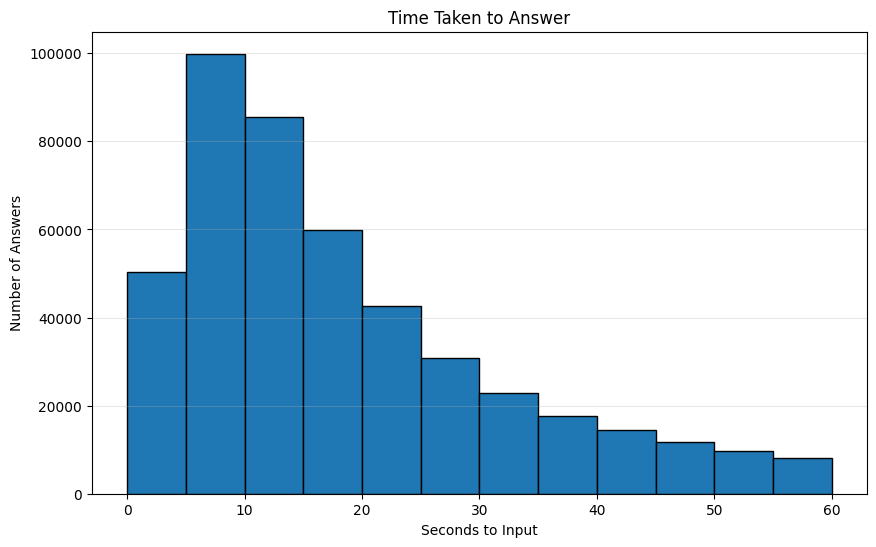

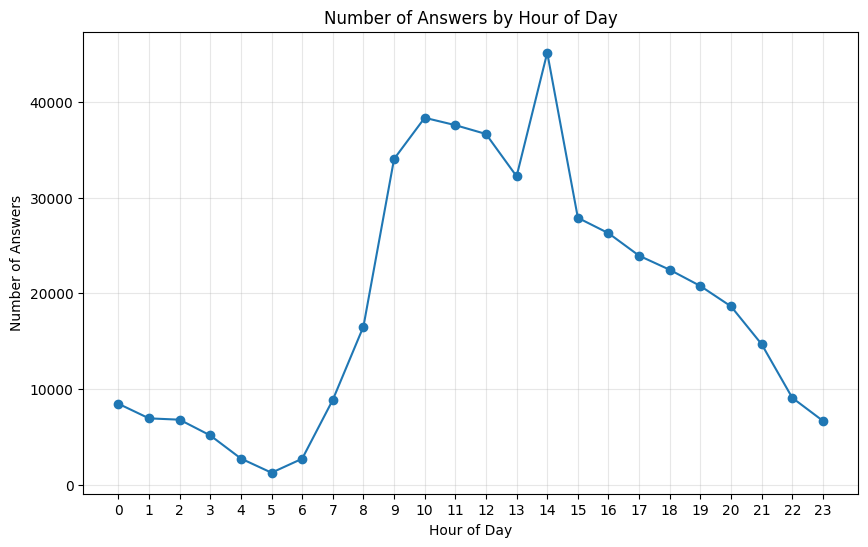

FINAL ANSWERS
1. Number of rows: 609588
2. Number of unique students: 19431
3. Proportion correct: 0.602166 (60.22%)
4. Mean time to input (minutes): 27.632971
5. The mean may not be representative because very large outliers can distort it.
6. A more representative value is the median: 27.632971 minutes
7. Number of rows after filtering: 453423

8. Answers per subject:
SubjectName
Number                  184452
Geometry and Measure    108027
Algebra                 100355
Data and Statistics      38203
dtype: int64


In [1]:
from numpy import median
# 1) Import the libraries, using the official docs:
# pandas main docs: https://pandas.pydata.org/docs/
# matplotlib pyplot docs: https://matplotlib.org/stable/api/pyplot_summary.html

import pandas as pd
import matplotlib.pyplot as plt

# 2) Loading the datasets: https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

student_answers = pd.read_csv("STUDENT_ANSWERS.csv")
question_subjects = pd.read_csv("QUESTION_SUBJECTS.csv")

print("Student answers downloaded:")
display(student_answers.head())

print("Question subjects downloaded:")
display(question_subjects.head())

#3) Exploring datasets using the following:
# DataFrame.shape:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html
# Series.nunique:
# https://pandas.pydata.org/docs/reference/api/pandas.Series.nunique.html
# Series.mean:
# https://pandas.pydata.org/docs/reference/api/pandas.Series.mean.html
# Series.median:
# https://pandas.pydata.org/docs/reference/api/pandas.Series.median.html

# 1) How many rows of data are there?
num_rows = student_answers.shape[0]
print("1. Number of rows:", num_rows)

#2) How many unique students are there?
unique_students = student_answers["UserId"].nunique()
print("2. Number of students:", unique_students)

#3) What proportion of answers are correct?
#IsCorrect is boolean, so mean() gives the proportion of True values
proportion_correct = student_answers["IsCorrect"].mean()
print("3. Proportion correct:", proportion_correct)
print("As a percentage:", f"{proportion_correct:2%}")

#4) What is the mean time to input an answer?
mean_seconds = student_answers["SecondsToInput"].mean()

mean_minutes = mean_seconds / 60
print("4. Mean time to input an answer:", mean_minutes, "minutes")
# round the value
print (" Rounded:", round(mean_minutes, 2))

#5 and 6
# The mean may not be representative if there are very large outliers.
# For example, a student may leave the page open for a long time.
# A more representative value is the median because it is less affected by extreme values.

median_seconds = student_answers["SecondsToInput"].median()
median_minutes = mean_seconds / 60
print("5. Median can be not representative since some large values in secondsToInput can pull the mean upwatd")
print("6. The median is more representative because it is less affected by outliers")
print("Median time to input an answer:", median_minutes)
print (" Rounded:", round(median_minutes, 2))

# 4) Filtering the data
# Boolean indexing / filtering:
# https://pandas.pydata.org/docs/user_guide/indexing.html

filtered_answers = student_answers[
    (student_answers["AnswerType"] == "Checkin") &
    (student_answers["SecondsToInput"] < 60)
].copy()

#7. What us the new number of rows in the dataset?
new_num_rows = filtered_answers.shape[0]
print("7.Number of rows after filtering:", new_num_rows)

print("Filtered data:")
display(filtered_answers.head())

#5) Merging the datasets
# pandas.merge:
# https://pandas.pydata.org/docs/reference/api/pandas.merge.html
# guide on merging:
# https://pandas.pydata.org/docs/user_guide/merging.html

# QuestionId as a key - exists in both datasets

merged_data = pd.merge(
    filtered_answers,
    question_subjects,
    on="QuestionId",
    how="left"
)

print ("Merged dataset preview:")
display(merged_data.head())

#6) Calcilating the answers per subject
# DataFrame.groupby:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
# Series.sort_values:
# https://pandas.pydata.org/docs/reference/api/pandas.Series.sort_values.html

answers_per_subject = (
    merged_data.groupby("SubjectName")
    .size()
    .sort_values(ascending=False)
)
print("8.Number of answers per SubjectName:")
print(answers_per_subject)

#7) Visualisation (Histogram)
#using the following docs:
# matplotlib.pyplot.figure:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html
# matplotlib.pyplot.hist:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html
# matplotlib.pyplot.xlabel:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xlabel.html
# matplotlib.pyplot.ylabel:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.ylabel.html
# matplotlib.pyplot.title:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.title.html
# matplotlib.pyplot.grid:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.grid.html
# matplotlib.pyplot.show:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html

plt.figure(figsize=(10,6))

# 12 equal width bins across 0 to 60 seconds means 5-second bins

plt.hist(
    merged_data["SecondsToInput"],
    bins=12,
    range=(0,60),
    edgecolor="black"
)

plt.title("Time Taken to Answer")
plt.xlabel("Seconds to Input")
plt.ylabel("Number of Answers")
plt.grid(axis="y", alpha=0.3)
plt.show()

#8) Visualisation (Line chart by hour of day)

# pandas.to_datetime:
# https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html
# Time series guide:
# https://pandas.pydata.org/docs/user_guide/timeseries.html
# Datetime hour accessor:
# https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.hour.html
# matplotlib.pyplot.plot:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
# matplotlib.pyplot.xticks:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xticks.html
# matplotlib.pyplot.legend:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html

#Convert DateAnswered to datetime
merged_data["DateAnswered"] = pd.to_datetime(merged_data["DateAnswered"])

#Extract hour of day from the datetime
merged_data["HourOfDay"] = merged_data["DateAnswered"].dt.hour
#Count answers for each hour
answers_per_hour = (
    merged_data.groupby("HourOfDay")
    .size()
    .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(10,6))
plt.plot(
    answers_per_hour.index,
    answers_per_hour.values,
    marker="o"
)

plt.title("Number of Answers by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Answers")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.show()


#9) Summary

print("FINAL ANSWERS")
print(f"1. Number of rows: {num_rows}")
print(f"2. Number of unique students: {unique_students}")
print(f"3. Proportion correct: {proportion_correct:.6f} ({proportion_correct:.2%})")
print(f"4. Mean time to input (minutes): {mean_minutes:.6f}")
print("5. The mean may not be representative because very large outliers can distort it.")
print(f"6. A more representative value is the median: {median_minutes:.6f} minutes")
print(f"7. Number of rows after filtering: {new_num_rows}")
print()
print("8. Answers per subject:")
print(answers_per_subject)


